In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

In [2]:
# ---------------------------------------------------------
# Project paths
# ---------------------------------------------------------

PROJECT_ROOT = Path("..")

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "neighbourhood_demand.csv"
)

TABLE_OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
)

FIGURE_OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
)

API_OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "api"
)

TABLE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
API_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Input data:", DATA_PATH.resolve())
print("Table outputs:", TABLE_OUTPUT_DIR.resolve())
print("Figure outputs:", FIGURE_OUTPUT_DIR.resolve())
print("API outputs:", API_OUTPUT_DIR.resolve())

Input data: C:\Users\tejas\OneDrive\Desktop\DRG_project\data\processed\neighbourhood_demand.csv
Table outputs: C:\Users\tejas\OneDrive\Desktop\DRG_project\outputs\tables
Figure outputs: C:\Users\tejas\OneDrive\Desktop\DRG_project\outputs\figures
API outputs: C:\Users\tejas\OneDrive\Desktop\DRG_project\outputs\api


In [3]:
# ---------------------------------------------------------
# Load processed demand data
# ---------------------------------------------------------

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Demand dataset could not be found at: {DATA_PATH.resolve()}"
    )

neighbourhood = pd.read_csv(DATA_PATH)

print("Original dataset shape:", neighbourhood.shape)
print("\nAvailable columns:")
print(neighbourhood.columns.tolist())

Original dataset shape: (39725, 2)

Available columns:
['datetime', 'total_demand_kwh']


In [4]:
# ---------------------------------------------------------
# Validate required columns
# ---------------------------------------------------------

required_columns = {
    "datetime",
    "total_demand_kwh"
}

missing_columns = required_columns.difference(
    neighbourhood.columns
)

if missing_columns:
    raise ValueError(
        "The following required columns are missing: "
        f"{sorted(missing_columns)}"
    )

neighbourhood["datetime"] = pd.to_datetime(
    neighbourhood["datetime"],
    errors="coerce"
)

neighbourhood["total_demand_kwh"] = pd.to_numeric(
    neighbourhood["total_demand_kwh"],
    errors="coerce"
)

missing_before_cleaning = (
    neighbourhood[
        ["datetime", "total_demand_kwh"]
    ]
    .isna()
    .sum()
)

print("Missing values before cleaning:")
print(missing_before_cleaning)

Missing values before cleaning:
datetime            0
total_demand_kwh    0
dtype: int64


In [5]:
# ---------------------------------------------------------
# Validate required columns
# ---------------------------------------------------------

required_columns = {
    "datetime",
    "total_demand_kwh"
}

missing_columns = required_columns.difference(
    neighbourhood.columns
)

if missing_columns:
    raise ValueError(
        "The following required columns are missing: "
        f"{sorted(missing_columns)}"
    )

neighbourhood["datetime"] = pd.to_datetime(
    neighbourhood["datetime"],
    errors="coerce"
)

neighbourhood["total_demand_kwh"] = pd.to_numeric(
    neighbourhood["total_demand_kwh"],
    errors="coerce"
)

missing_before_cleaning = (
    neighbourhood[
        ["datetime", "total_demand_kwh"]
    ]
    .isna()
    .sum()
)

print("Missing values before cleaning:")
print(missing_before_cleaning)

Missing values before cleaning:
datetime            0
total_demand_kwh    0
dtype: int64


In [6]:
# ---------------------------------------------------------
# Clean and filter dataset
# ---------------------------------------------------------

neighbourhood = (
    neighbourhood
    .dropna(
        subset=[
            "datetime",
            "total_demand_kwh"
        ]
    )
    .sort_values("datetime")
    .drop_duplicates(
        subset=["datetime"],
        keep="first"
    )
    .reset_index(drop=True)
)

neighbourhood = neighbourhood[
    neighbourhood["datetime"] >= "2013-01-01"
].copy()

neighbourhood.reset_index(
    drop=True,
    inplace=True
)

print("Filtered dataset shape:", neighbourhood.shape)
print(
    "Date range:",
    neighbourhood["datetime"].min(),
    "to",
    neighbourhood["datetime"].max()
)

print(
    "Number of observations:",
    len(neighbourhood)
)

Filtered dataset shape: (20305, 2)
Date range: 2013-01-01 00:00:00 to 2014-02-28 00:00:00
Number of observations: 20305


In [7]:
# ---------------------------------------------------------
# Dataset validation
# ---------------------------------------------------------

assert len(neighbourhood) > 0, (
    "No observations remain after filtering."
)

assert neighbourhood["datetime"].notna().all(), (
    "Datetime contains missing values."
)

assert neighbourhood["total_demand_kwh"].notna().all(), (
    "Demand contains missing values."
)

assert (
    neighbourhood["total_demand_kwh"] >= 0
).all(), (
    "Negative demand values were detected."
)

print("Dataset validation passed.")

Dataset validation passed.


In [8]:
# ---------------------------------------------------------
# Create time-based features
# ---------------------------------------------------------

neighbourhood["hour"] = (
    neighbourhood["datetime"].dt.hour
)

neighbourhood["month"] = (
    neighbourhood["datetime"].dt.month
)

neighbourhood["year"] = (
    neighbourhood["datetime"].dt.year
)

neighbourhood["day_of_week"] = (
    neighbourhood["datetime"].dt.dayofweek
)

neighbourhood["is_weekend"] = (
    neighbourhood["day_of_week"] >= 5
).astype(int)

neighbourhood["is_winter"] = (
    neighbourhood["month"]
    .isin([12, 1, 2])
).astype(int)

In [9]:
# ---------------------------------------------------------
# Create EV charging indicator
# ---------------------------------------------------------

neighbourhood["ev_charging_period"] = (
    neighbourhood["hour"]
    .between(17, 21)
).astype(int)


# ---------------------------------------------------------
# Create heat pump operating indicator
# ---------------------------------------------------------

morning_heating_period = (
    neighbourhood["hour"]
    .between(6, 9)
)

evening_heating_period = (
    neighbourhood["hour"]
    .between(17, 22)
)

neighbourhood["heating_period"] = (
    morning_heating_period
    | evening_heating_period
).astype(int)

neighbourhood["hp_operating_period"] = (
    neighbourhood["is_winter"]
    * neighbourhood["heating_period"]
).astype(int)

In [10]:
# ---------------------------------------------------------
# Validate operating indicators
# ---------------------------------------------------------

print("EV charging indicator counts:")
print(
    neighbourhood[
        "ev_charging_period"
    ].value_counts().sort_index()
)

print("\nHeat pump operating indicator counts:")
print(
    neighbourhood[
        "hp_operating_period"
    ].value_counts().sort_index()
)

assert set(
    neighbourhood[
        "ev_charging_period"
    ].unique()
).issubset({0, 1}), (
    "EV charging indicator contains invalid values."
)

assert set(
    neighbourhood[
        "hp_operating_period"
    ].unique()
).issubset({0, 1}), (
    "Heat pump indicator contains invalid values."
)

assert (
    neighbourhood.loc[
        neighbourhood["hp_operating_period"] == 1,
        "is_winter"
    ] == 1
).all(), (
    "Heat pump load was assigned outside winter."
)

print("\nOperating-indicator validation passed.")

EV charging indicator counts:
ev_charging_period
0    16075
1     4230
Name: count, dtype: int64

Heat pump operating indicator counts:
hp_operating_period
0    17345
1     2960
Name: count, dtype: int64

Operating-indicator validation passed.


In [11]:
# ---------------------------------------------------------
# Validate operating indicators
# ---------------------------------------------------------

print("EV charging indicator counts:")
print(
    neighbourhood[
        "ev_charging_period"
    ].value_counts().sort_index()
)

print("\nHeat pump operating indicator counts:")
print(
    neighbourhood[
        "hp_operating_period"
    ].value_counts().sort_index()
)

assert set(
    neighbourhood[
        "ev_charging_period"
    ].unique()
).issubset({0, 1}), (
    "EV charging indicator contains invalid values."
)

assert set(
    neighbourhood[
        "hp_operating_period"
    ].unique()
).issubset({0, 1}), (
    "Heat pump indicator contains invalid values."
)

assert (
    neighbourhood.loc[
        neighbourhood["hp_operating_period"] == 1,
        "is_winter"
    ] == 1
).all(), (
    "Heat pump load was assigned outside winter."
)

print("\nOperating-indicator validation passed.")

EV charging indicator counts:
ev_charging_period
0    16075
1     4230
Name: count, dtype: int64

Heat pump operating indicator counts:
hp_operating_period
0    17345
1     2960
Name: count, dtype: int64

Operating-indicator validation passed.


In [12]:
indicator_preview = neighbourhood[
    [
        "datetime",
        "total_demand_kwh",
        "hour",
        "month",
        "is_winter",
        "ev_charging_period",
        "hp_operating_period"
    ]
].head(30)

indicator_preview

,datetime,total_demand_kwh,hour,month,is_winter,ev_charging_period,hp_operating_period
0,2013-01-01 00:00:00,220.0130,0,1,1,0,0
1,2013-01-01 00:30:00,204.2700,0,1,1,0,0
2,2013-01-01 01:00:00,189.4390,1,1,1,0,0
3,2013-01-01 01:30:00,173.0190,1,1,1,0,0
4,2013-01-01 02:00:00,154.5370,2,1,1,0,0
5,2013-01-01 02:30:00,147.2550,2,1,1,0,0
6,2013-01-01 03:00:00,138.9520,3,1,1,0,0
7,2013-01-01 03:30:00,129.9930,3,1,1,0,0
8,2013-01-01 04:00:00,120.9710,4,1,1,0,0
9,2013-01-01 04:30:00,119.4930,4,1,1,0,0


In [13]:
# ---------------------------------------------------------
# Calculate baseline stress threshold
# ---------------------------------------------------------

stress_threshold = float(
    neighbourhood[
        "total_demand_kwh"
    ].quantile(0.95)
)

neighbourhood["baseline_stress_event"] = (
    neighbourhood["total_demand_kwh"]
    > stress_threshold
).astype(int)

baseline_stress_events = int(
    neighbourhood[
        "baseline_stress_event"
    ].sum()
)

baseline_stress_percentage = float(
    (
        baseline_stress_events
        / len(neighbourhood)
    )
    * 100
)

baseline_peak_demand = float(
    neighbourhood[
        "total_demand_kwh"
    ].max()
)

print(
    f"Stress threshold: "
    f"{stress_threshold:.4f} kWh"
)

print(
    f"Number of observations: "
    f"{len(neighbourhood):,}"
)

print(
    f"Baseline stress events: "
    f"{baseline_stress_events:,}"
)

print(
    f"Baseline stress percentage: "
    f"{baseline_stress_percentage:.4f}%"
)

print(
    f"Baseline peak demand: "
    f"{baseline_peak_demand:.4f} kWh"
)

Stress threshold: 354.5756 kWh
Number of observations: 20,305
Baseline stress events: 1,016
Baseline stress percentage: 5.0037%
Baseline peak demand: 464.9160 kWh


In [14]:
# ---------------------------------------------------------
# Validate baseline results
# ---------------------------------------------------------

EXPECTED_OBSERVATIONS = 20_209
EXPECTED_THRESHOLD = 354.1552
EXPECTED_BASELINE_EVENTS = 1_011

print("Baseline validation report")
print("-" * 50)

print(
    "Observation check:",
    len(neighbourhood),
    "expected approximately",
    EXPECTED_OBSERVATIONS
)

print(
    "Threshold check:",
    round(stress_threshold, 4),
    "expected approximately",
    EXPECTED_THRESHOLD
)

print(
    "Baseline stress-event check:",
    baseline_stress_events,
    "expected approximately",
    EXPECTED_BASELINE_EVENTS
)

if len(neighbourhood) != EXPECTED_OBSERVATIONS:
    print(
        "\nWarning: the observation count differs from the "
        "accepted Phase 8 value. Check the input file and "
        "date filtering before using the results."
    )

if not np.isclose(
    stress_threshold,
    EXPECTED_THRESHOLD,
    atol=0.05
):
    print(
        "\nWarning: the threshold differs from the accepted "
        "Phase 8 threshold."
    )

if baseline_stress_events != EXPECTED_BASELINE_EVENTS:
    print(
        "\nWarning: the baseline stress count differs from "
        "the accepted Phase 8 result."
    )

Baseline validation report
--------------------------------------------------
Observation check: 20305 expected approximately 20209
Threshold check: 354.5756 expected approximately 354.1552
Baseline stress-event check: 1016 expected approximately 1011





In [15]:
# ---------------------------------------------------------
# Define combined electrification scenarios
# ---------------------------------------------------------

scenarios = {
    "Baseline": {
        "ev_load_kwh": 0.0,
        "hp_load_kwh": 0.0
    },
    "Low": {
        "ev_load_kwh": 20.0,
        "hp_load_kwh": 10.0
    },
    "Medium": {
        "ev_load_kwh": 40.0,
        "hp_load_kwh": 20.0
    },
    "High": {
        "ev_load_kwh": 60.0,
        "hp_load_kwh": 30.0
    },
    "Extreme": {
        "ev_load_kwh": 80.0,
        "hp_load_kwh": 40.0
    }
}

scenario_table = pd.DataFrame(
    [
        {
            "Scenario": scenario_name,
            "EV_Load_kWh": values[
                "ev_load_kwh"
            ],
            "HP_Load_kWh": values[
                "hp_load_kwh"
            ]
        }
        for scenario_name, values
        in scenarios.items()
    ]
)

scenario_table

,Scenario,EV_Load_kWh,HP_Load_kWh
0,Baseline,0.0000,0.0000
1,Low,20.0000,10.0000
2,Medium,40.0000,20.0000
3,High,60.0000,30.0000
4,Extreme,80.0000,40.0000


In [16]:
def run_combined_scenario(
    demand_data: pd.DataFrame,
    ev_extra_load_kwh: float,
    hp_extra_load_kwh: float,
    threshold_kwh: float,
    scenario_name: str = "Custom"
) -> tuple[dict, pd.DataFrame]:
    """
    Simulate combined EV and heat pump electricity demand.

    Parameters
    ----------
    demand_data:
        DataFrame containing historical demand and binary
        operating-period indicators.

    ev_extra_load_kwh:
        Additional neighbourhood EV demand applied during
        the EV charging period.

    hp_extra_load_kwh:
        Additional neighbourhood heat pump demand applied
        during winter heating periods.

    threshold_kwh:
        Demand threshold above which an observation is
        classified as a grid-stress event.

    scenario_name:
        Name assigned to the scenario.

    Returns
    -------
    summary:
        Dictionary containing scenario-level metrics.

    detailed:
        DataFrame containing time-series scenario results.
    """

    required = {
        "datetime",
        "total_demand_kwh",
        "ev_charging_period",
        "hp_operating_period"
    }

    missing = required.difference(
        demand_data.columns
    )

    if missing:
        raise ValueError(
            "Missing required simulation columns: "
            f"{sorted(missing)}"
        )

    if ev_extra_load_kwh < 0:
        raise ValueError(
            "EV load cannot be negative."
        )

    if hp_extra_load_kwh < 0:
        raise ValueError(
            "Heat pump load cannot be negative."
        )

    if threshold_kwh <= 0:
        raise ValueError(
            "The stress threshold must be positive."
        )

    detailed = demand_data.copy()

    detailed[
        "scenario"
    ] = scenario_name

    detailed[
        "ev_additional_demand_kwh"
    ] = (
        detailed["ev_charging_period"]
        * float(ev_extra_load_kwh)
    )

    detailed[
        "hp_additional_demand_kwh"
    ] = (
        detailed["hp_operating_period"]
        * float(hp_extra_load_kwh)
    )

    detailed[
        "total_additional_demand_kwh"
    ] = (
        detailed[
            "ev_additional_demand_kwh"
        ]
        + detailed[
            "hp_additional_demand_kwh"
        ]
    )

    detailed[
        "future_demand_kwh"
    ] = (
        detailed["total_demand_kwh"]
        + detailed[
            "total_additional_demand_kwh"
        ]
    )

    detailed[
        "future_stress_event"
    ] = (
        detailed["future_demand_kwh"]
        > threshold_kwh
    ).astype(int)

    stress_events = int(
        detailed[
            "future_stress_event"
        ].sum()
    )

    stress_percentage = float(
        stress_events
        / len(detailed)
        * 100
    )

    future_peak_demand = float(
        detailed[
            "future_demand_kwh"
        ].max()
    )

    mean_future_demand = float(
        detailed[
            "future_demand_kwh"
        ].mean()
    )

    total_additional_demand = float(
        detailed[
            "total_additional_demand_kwh"
        ].sum()
    )

    stress_event_increase = (
        stress_events
        - baseline_stress_events
    )

    stress_percentage_point_increase = (
        stress_percentage
        - baseline_stress_percentage
    )

    peak_demand_increase = (
        future_peak_demand
        - baseline_peak_demand
    )

    summary = {
        "Scenario": scenario_name,
        "EV_Load_kWh": float(
            ev_extra_load_kwh
        ),
        "HP_Load_kWh": float(
            hp_extra_load_kwh
        ),
        "Observations": int(
            len(detailed)
        ),
        "Stress_Threshold_kWh": float(
            threshold_kwh
        ),
        "Stress_Events": stress_events,
        "Stress_Percentage": (
            stress_percentage
        ),
        "Stress_Event_Increase": (
            stress_event_increase
        ),
        "Stress_Percentage_Point_Increase": (
            stress_percentage_point_increase
        ),
        "Baseline_Peak_Demand_kWh": (
            baseline_peak_demand
        ),
        "Future_Peak_Demand_kWh": (
            future_peak_demand
        ),
        "Peak_Demand_Increase_kWh": (
            peak_demand_increase
        ),
        "Mean_Future_Demand_kWh": (
            mean_future_demand
        ),
        "Total_Additional_Demand_kWh": (
            total_additional_demand
        )
    }

    return summary, detailed

In [17]:
# ---------------------------------------------------------
# Run predefined scenarios
# ---------------------------------------------------------

combined_summary_records = []
combined_detailed_outputs = {}

for scenario_name, parameters in scenarios.items():

    summary, detailed = run_combined_scenario(
        demand_data=neighbourhood,
        ev_extra_load_kwh=parameters[
            "ev_load_kwh"
        ],
        hp_extra_load_kwh=parameters[
            "hp_load_kwh"
        ],
        threshold_kwh=stress_threshold,
        scenario_name=scenario_name
    )

    combined_summary_records.append(
        summary
    )

    combined_detailed_outputs[
        scenario_name
    ] = detailed

combined_results = pd.DataFrame(
    combined_summary_records
)

scenario_order = [
    "Baseline",
    "Low",
    "Medium",
    "High",
    "Extreme"
]

combined_results[
    "Scenario"
] = pd.Categorical(
    combined_results["Scenario"],
    categories=scenario_order,
    ordered=True
)

combined_results = (
    combined_results
    .sort_values("Scenario")
    .reset_index(drop=True)
)

combined_results

,Scenario,EV_Load_kWh,HP_Load_kWh,Observations,Stress_Threshold_kWh,Stress_Events,Stress_Percentage,Stress_Event_Increase,Stress_Percentage_Point_Increase,Baseline_Peak_Demand_kWh,Future_Peak_Demand_kWh,Peak_Demand_Increase_kWh,Mean_Future_Demand_kWh,Total_Additional_Demand_kWh
0,Baseline,0.0000,0.0000,20305,354.5756,1016,5.0037,0,0.0000,464.9160,464.9160,0.0000,204.2057,0.0000
1,Low,20.0000,10.0000,20305,354.5756,1624,7.9980,608,2.9943,464.9160,494.9160,30.0000,209.8299,"114,200.0000"
2,Medium,40.0000,20.0000,20305,354.5756,2032,10.0074,1016,5.0037,464.9160,524.9160,60.0000,215.4542,"228,400.0000"
3,High,60.0000,30.0000,20305,354.5756,2346,11.5538,1330,6.5501,464.9160,554.9160,90.0000,221.0784,"342,600.0000"
4,Extreme,80.0000,40.0000,20305,354.5756,2642,13.0116,1626,8.0079,464.9160,584.9160,120.0000,226.7026,"456,800.0000"


In [18]:
# ---------------------------------------------------------
# Display key scenario results
# ---------------------------------------------------------

key_results = combined_results[
    [
        "Scenario",
        "EV_Load_kWh",
        "HP_Load_kWh",
        "Stress_Events",
        "Stress_Percentage",
        "Stress_Event_Increase",
        "Stress_Percentage_Point_Increase",
        "Future_Peak_Demand_kWh",
        "Peak_Demand_Increase_kWh"
    ]
].copy()

key_results[
    "Stress_Percentage"
] = key_results[
    "Stress_Percentage"
].round(4)

key_results[
    "Stress_Percentage_Point_Increase"
] = key_results[
    "Stress_Percentage_Point_Increase"
].round(4)

key_results[
    "Future_Peak_Demand_kWh"
] = key_results[
    "Future_Peak_Demand_kWh"
].round(4)

key_results[
    "Peak_Demand_Increase_kWh"
] = key_results[
    "Peak_Demand_Increase_kWh"
].round(4)

key_results

,Scenario,EV_Load_kWh,HP_Load_kWh,Stress_Events,Stress_Percentage,Stress_Event_Increase,Stress_Percentage_Point_Increase,Future_Peak_Demand_kWh,Peak_Demand_Increase_kWh
0,Baseline,0.0000,0.0000,1016,5.0037,0,0.0000,464.9160,0.0000
1,Low,20.0000,10.0000,1624,7.9980,608,2.9943,494.9160,30.0000
2,Medium,40.0000,20.0000,2032,10.0074,1016,5.0037,524.9160,60.0000
3,High,60.0000,30.0000,2346,11.5538,1330,6.5501,554.9160,90.0000
4,Extreme,80.0000,40.0000,2642,13.0116,1626,8.0079,584.9160,120.0000


In [19]:
# ---------------------------------------------------------
# Validate simulation behaviour
# ---------------------------------------------------------

stress_event_values = (
    combined_results[
        "Stress_Events"
    ]
    .to_numpy()
)

stress_percentage_values = (
    combined_results[
        "Stress_Percentage"
    ]
    .to_numpy()
)

peak_demand_values = (
    combined_results[
        "Future_Peak_Demand_kWh"
    ]
    .to_numpy()
)

assert np.all(
    np.diff(stress_event_values) >= 0
), (
    "Stress events do not increase monotonically."
)

assert np.all(
    np.diff(stress_percentage_values) >= 0
), (
    "Stress percentages do not increase monotonically."
)

assert np.all(
    np.diff(peak_demand_values) >= 0
), (
    "Peak demand does not increase monotonically."
)

baseline_row = combined_results.loc[
    combined_results["Scenario"]
    == "Baseline"
].iloc[0]

assert int(
    baseline_row["Stress_Events"]
) == baseline_stress_events

assert np.isclose(
    float(
        baseline_row[
            "Stress_Percentage"
        ]
    ),
    baseline_stress_percentage
)

print(
    "Scenario validation passed. Stress events, "
    "stress percentages and peak demand increase "
    "monotonically across the scenarios."
)

Scenario validation passed. Stress events, stress percentages and peak demand increase monotonically across the scenarios.


In [20]:
# ---------------------------------------------------------
# Automatically summarise key findings
# ---------------------------------------------------------

baseline_result = combined_results.loc[
    combined_results["Scenario"]
    == "Baseline"
].iloc[0]

extreme_result = combined_results.loc[
    combined_results["Scenario"]
    == "Extreme"
].iloc[0]

print("Combined electrification results")
print("-" * 60)

print(
    f"Baseline stress events: "
    f"{int(baseline_result['Stress_Events']):,}"
)

print(
    f"Extreme-scenario stress events: "
    f"{int(extreme_result['Stress_Events']):,}"
)

print(
    f"Increase in stress events: "
    f"{int(extreme_result['Stress_Event_Increase']):,}"
)

print(
    f"Baseline stress percentage: "
    f"{baseline_result['Stress_Percentage']:.4f}%"
)

print(
    f"Extreme stress percentage: "
    f"{extreme_result['Stress_Percentage']:.4f}%"
)

print(
    f"Extreme future peak demand: "
    f"{extreme_result['Future_Peak_Demand_kWh']:.4f} kWh"
)

Combined electrification results
------------------------------------------------------------
Baseline stress events: 1,016
Extreme-scenario stress events: 2,642
Increase in stress events: 1,626
Baseline stress percentage: 5.0037%
Extreme stress percentage: 13.0116%
Extreme future peak demand: 584.9160 kWh


In [21]:
# ---------------------------------------------------------
# Automatically summarise key findings
# ---------------------------------------------------------

baseline_result = combined_results.loc[
    combined_results["Scenario"]
    == "Baseline"
].iloc[0]

extreme_result = combined_results.loc[
    combined_results["Scenario"]
    == "Extreme"
].iloc[0]

print("Combined electrification results")
print("-" * 60)

print(
    f"Baseline stress events: "
    f"{int(baseline_result['Stress_Events']):,}"
)

print(
    f"Extreme-scenario stress events: "
    f"{int(extreme_result['Stress_Events']):,}"
)

print(
    f"Increase in stress events: "
    f"{int(extreme_result['Stress_Event_Increase']):,}"
)

print(
    f"Baseline stress percentage: "
    f"{baseline_result['Stress_Percentage']:.4f}%"
)

print(
    f"Extreme stress percentage: "
    f"{extreme_result['Stress_Percentage']:.4f}%"
)

print(
    f"Extreme future peak demand: "
    f"{extreme_result['Future_Peak_Demand_kWh']:.4f} kWh"
)

Combined electrification results
------------------------------------------------------------
Baseline stress events: 1,016
Extreme-scenario stress events: 2,642
Increase in stress events: 1,626
Baseline stress percentage: 5.0037%
Extreme stress percentage: 13.0116%
Extreme future peak demand: 584.9160 kWh


In [22]:
# ---------------------------------------------------------
# Automatically summarise key findings
# ---------------------------------------------------------

baseline_result = combined_results.loc[
    combined_results["Scenario"]
    == "Baseline"
].iloc[0]

extreme_result = combined_results.loc[
    combined_results["Scenario"]
    == "Extreme"
].iloc[0]

print("Combined electrification results")
print("-" * 60)

print(
    f"Baseline stress events: "
    f"{int(baseline_result['Stress_Events']):,}"
)

print(
    f"Extreme-scenario stress events: "
    f"{int(extreme_result['Stress_Events']):,}"
)

print(
    f"Increase in stress events: "
    f"{int(extreme_result['Stress_Event_Increase']):,}"
)

print(
    f"Baseline stress percentage: "
    f"{baseline_result['Stress_Percentage']:.4f}%"
)

print(
    f"Extreme stress percentage: "
    f"{extreme_result['Stress_Percentage']:.4f}%"
)

print(
    f"Extreme future peak demand: "
    f"{extreme_result['Future_Peak_Demand_kWh']:.4f} kWh"
)

Combined electrification results
------------------------------------------------------------
Baseline stress events: 1,016
Extreme-scenario stress events: 2,642
Increase in stress events: 1,626
Baseline stress percentage: 5.0037%
Extreme stress percentage: 13.0116%
Extreme future peak demand: 584.9160 kWh


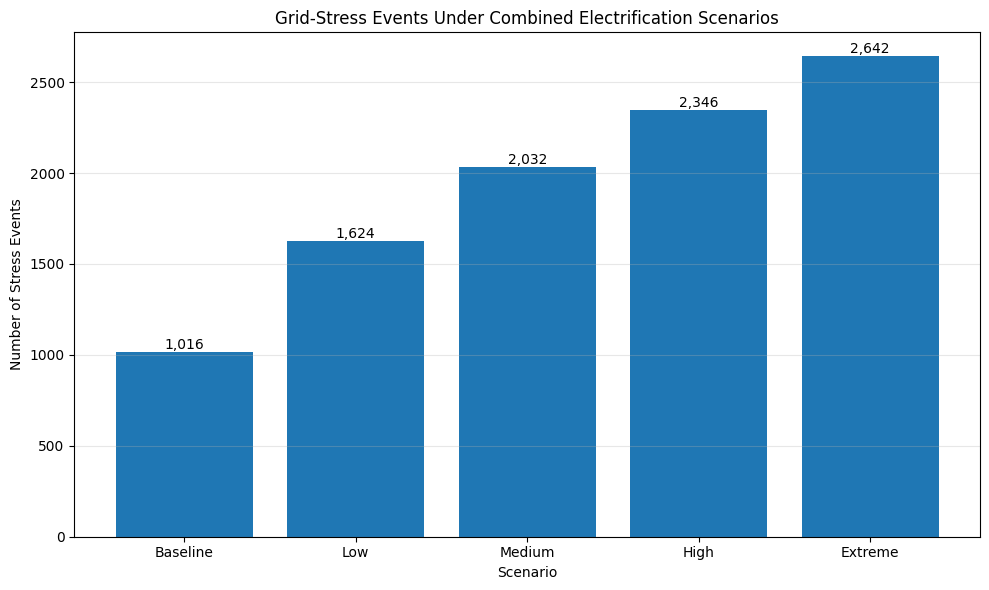

Saved figure: ..\outputs\figures\phase11_combined_stress_events.png


In [23]:
# ---------------------------------------------------------
# Figure 1: Stress events by scenario
# ---------------------------------------------------------

plot_data = combined_results.copy()

fig, ax = plt.subplots(
    figsize=(10, 6)
)

bars = ax.bar(
    plot_data[
        "Scenario"
    ].astype(str),
    plot_data[
        "Stress_Events"
    ]
)

ax.set_title(
    "Grid-Stress Events Under Combined "
    "Electrification Scenarios"
)

ax.set_xlabel(
    "Scenario"
)

ax.set_ylabel(
    "Number of Stress Events"
)

ax.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(
    bars,
    plot_data["Stress_Events"]
):
    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

stress_events_figure_path = (
    FIGURE_OUTPUT_DIR
    / "phase11_combined_stress_events.png"
)

plt.savefig(
    stress_events_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved figure:",
    stress_events_figure_path
)

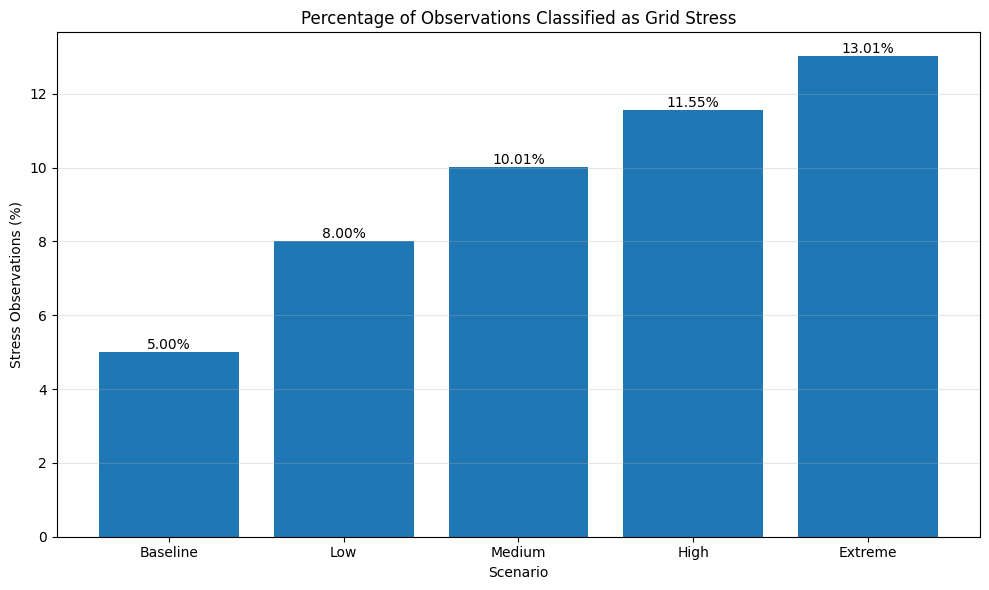

Saved figure: ..\outputs\figures\phase11_combined_stress_percentage.png


In [24]:
# ---------------------------------------------------------
# Figure 2: Stress percentage by scenario
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 6)
)

bars = ax.bar(
    plot_data[
        "Scenario"
    ].astype(str),
    plot_data[
        "Stress_Percentage"
    ]
)

ax.set_title(
    "Percentage of Observations Classified "
    "as Grid Stress"
)

ax.set_xlabel(
    "Scenario"
)

ax.set_ylabel(
    "Stress Observations (%)"
)

ax.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(
    bars,
    plot_data[
        "Stress_Percentage"
    ]
):
    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

stress_percentage_figure_path = (
    FIGURE_OUTPUT_DIR
    / "phase11_combined_stress_percentage.png"
)

plt.savefig(
    stress_percentage_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved figure:",
    stress_percentage_figure_path
)

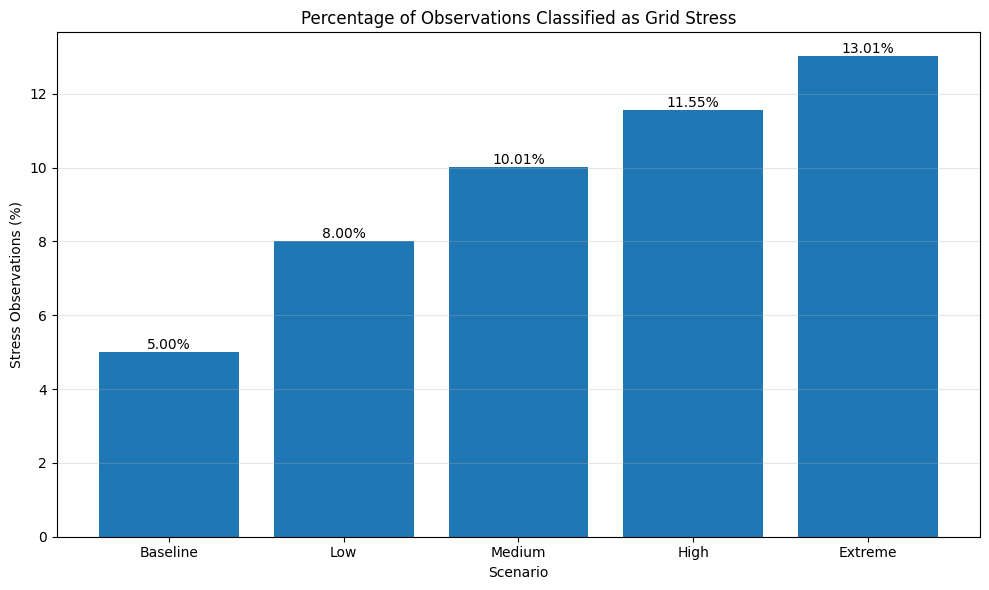

Saved figure: ..\outputs\figures\phase11_combined_stress_percentage.png


In [25]:
# ---------------------------------------------------------
# Figure 2: Stress percentage by scenario
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 6)
)

bars = ax.bar(
    plot_data[
        "Scenario"
    ].astype(str),
    plot_data[
        "Stress_Percentage"
    ]
)

ax.set_title(
    "Percentage of Observations Classified "
    "as Grid Stress"
)

ax.set_xlabel(
    "Scenario"
)

ax.set_ylabel(
    "Stress Observations (%)"
)

ax.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(
    bars,
    plot_data[
        "Stress_Percentage"
    ]
):
    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

stress_percentage_figure_path = (
    FIGURE_OUTPUT_DIR
    / "phase11_combined_stress_percentage.png"
)

plt.savefig(
    stress_percentage_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved figure:",
    stress_percentage_figure_path
)

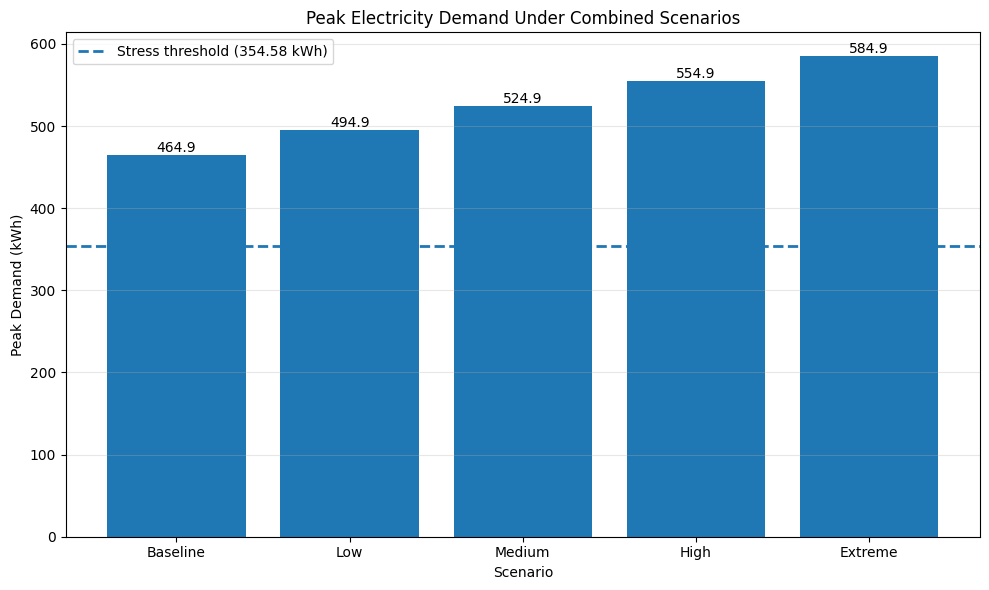

Saved figure: ..\outputs\figures\phase11_combined_peak_demand.png


In [26]:
# ---------------------------------------------------------
# Figure 3: Peak demand by scenario
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 6)
)

bars = ax.bar(
    plot_data[
        "Scenario"
    ].astype(str),
    plot_data[
        "Future_Peak_Demand_kWh"
    ]
)

ax.axhline(
    y=stress_threshold,
    linestyle="--",
    linewidth=2,
    label=(
        f"Stress threshold "
        f"({stress_threshold:.2f} kWh)"
    )
)

ax.set_title(
    "Peak Electricity Demand Under Combined Scenarios"
)

ax.set_xlabel(
    "Scenario"
)

ax.set_ylabel(
    "Peak Demand (kWh)"
)

ax.grid(
    axis="y",
    alpha=0.3
)

ax.legend()

for bar, value in zip(
    bars,
    plot_data[
        "Future_Peak_Demand_kWh"
    ]
):
    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

peak_demand_figure_path = (
    FIGURE_OUTPUT_DIR
    / "phase11_combined_peak_demand.png"
)

plt.savefig(
    peak_demand_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved figure:",
    peak_demand_figure_path
)

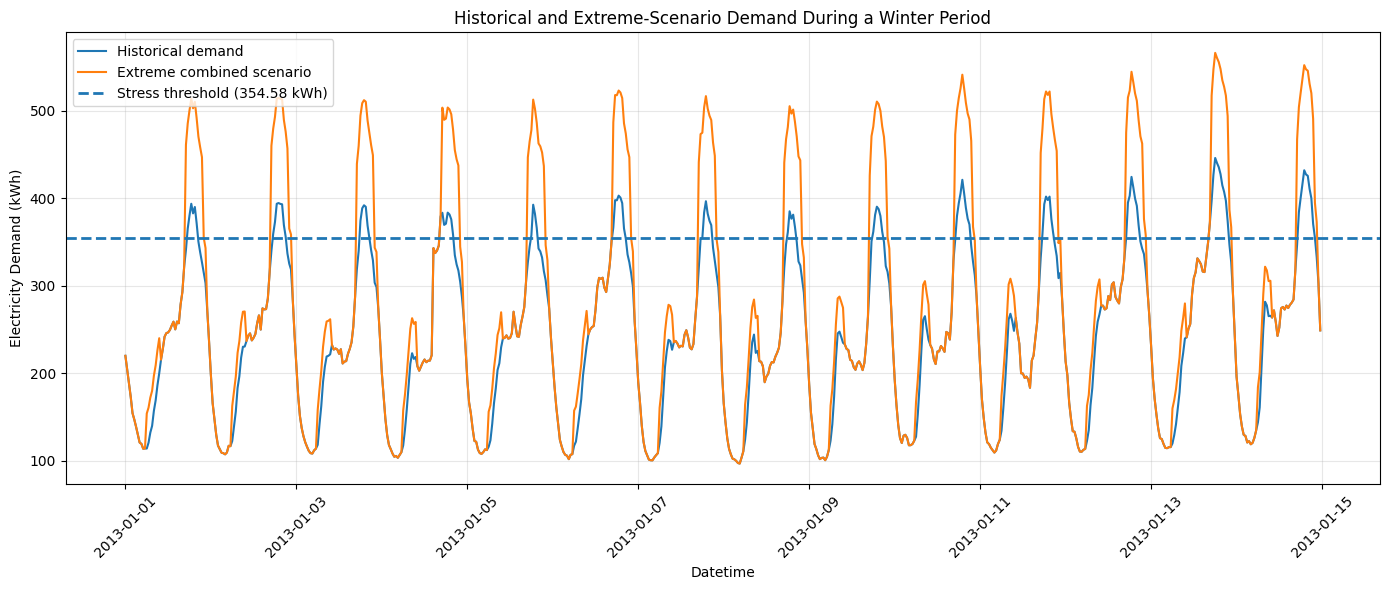

Saved figure: ..\outputs\figures\phase11_historical_vs_extreme_demand.png


In [27]:
# ---------------------------------------------------------
# Figure 4: Historical versus extreme future demand
# ---------------------------------------------------------

extreme_output = (
    combined_detailed_outputs[
        "Extreme"
    ]
    .copy()
)

# Use a focused winter period so the impact is visible.
winter_start = pd.Timestamp(
    "2013-01-01"
)

winter_end = pd.Timestamp(
    "2013-01-14 23:59:59"
)

comparison_period = extreme_output[
    extreme_output["datetime"]
    .between(
        winter_start,
        winter_end
    )
].copy()

if comparison_period.empty:
    comparison_period = (
        extreme_output
        .head(48 * 14)
        .copy()
    )

fig, ax = plt.subplots(
    figsize=(14, 6)
)

ax.plot(
    comparison_period["datetime"],
    comparison_period[
        "total_demand_kwh"
    ],
    label="Historical demand",
    linewidth=1.5
)

ax.plot(
    comparison_period["datetime"],
    comparison_period[
        "future_demand_kwh"
    ],
    label="Extreme combined scenario",
    linewidth=1.5
)

ax.axhline(
    y=stress_threshold,
    linestyle="--",
    linewidth=2,
    label=(
        f"Stress threshold "
        f"({stress_threshold:.2f} kWh)"
    )
)

ax.set_title(
    "Historical and Extreme-Scenario Demand "
    "During a Winter Period"
)

ax.set_xlabel(
    "Datetime"
)

ax.set_ylabel(
    "Electricity Demand (kWh)"
)

ax.grid(
    alpha=0.3
)

ax.legend()

plt.xticks(
    rotation=45
)

plt.tight_layout()

time_series_figure_path = (
    FIGURE_OUTPUT_DIR
    / "phase11_historical_vs_extreme_demand.png"
)

plt.savefig(
    time_series_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved figure:",
    time_series_figure_path
)

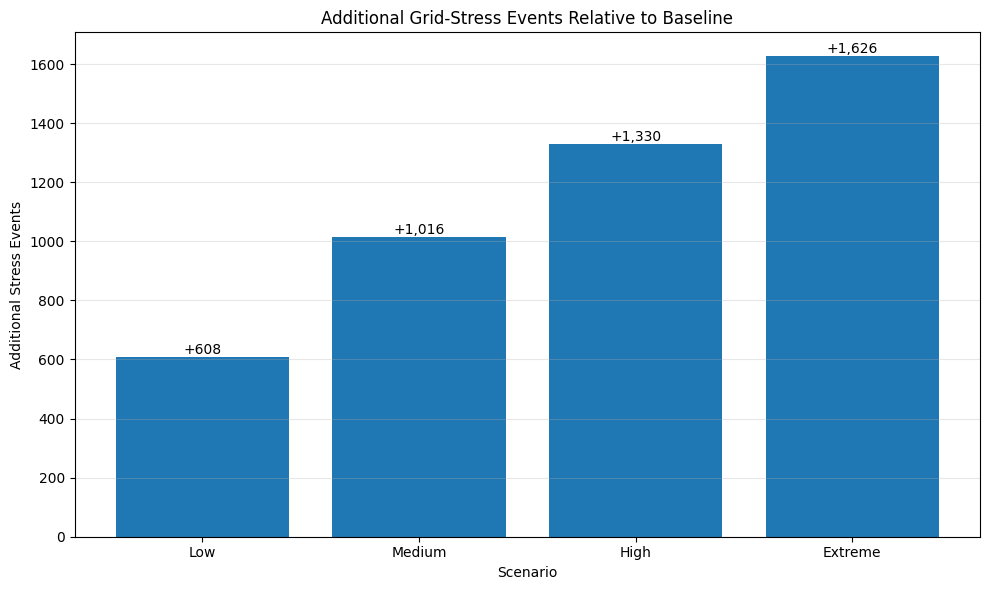

Saved figure: ..\outputs\figures\phase11_additional_stress_events.png


In [28]:
# ---------------------------------------------------------
# Figure 5: Additional stress events relative to baseline
# ---------------------------------------------------------

non_baseline_results = combined_results[
    combined_results["Scenario"]
    != "Baseline"
].copy()

fig, ax = plt.subplots(
    figsize=(10, 6)
)

bars = ax.bar(
    non_baseline_results[
        "Scenario"
    ].astype(str),
    non_baseline_results[
        "Stress_Event_Increase"
    ]
)

ax.set_title(
    "Additional Grid-Stress Events Relative to Baseline"
)

ax.set_xlabel(
    "Scenario"
)

ax.set_ylabel(
    "Additional Stress Events"
)

ax.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(
    bars,
    non_baseline_results[
        "Stress_Event_Increase"
    ]
):
    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"+{int(value):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

incremental_figure_path = (
    FIGURE_OUTPUT_DIR
    / "phase11_additional_stress_events.png"
)

plt.savefig(
    incremental_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved figure:",
    incremental_figure_path
)

In [29]:
# ---------------------------------------------------------
# Prepare detailed time-series outputs
# ---------------------------------------------------------

detailed_columns = [
    "datetime",
    "total_demand_kwh",
    "hour",
    "month",
    "is_winter",
    "ev_charging_period",
    "hp_operating_period",
    "ev_additional_demand_kwh",
    "hp_additional_demand_kwh",
    "total_additional_demand_kwh",
    "future_demand_kwh",
    "future_stress_event",
    "scenario"
]

high_scenario_output = (
    combined_detailed_outputs[
        "High"
    ][detailed_columns]
    .copy()
)

extreme_scenario_output = (
    combined_detailed_outputs[
        "Extreme"
    ][detailed_columns]
    .copy()
)

extreme_stress_events = (
    extreme_scenario_output[
        extreme_scenario_output[
            "future_stress_event"
        ] == 1
    ]
    .sort_values(
        "future_demand_kwh",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "High scenario observations:",
    len(high_scenario_output)
)

print(
    "Extreme scenario observations:",
    len(extreme_scenario_output)
)

print(
    "Extreme scenario stress events:",
    len(extreme_stress_events)
)

High scenario observations: 20305
Extreme scenario observations: 20305
Extreme scenario stress events: 2642


In [30]:
# ---------------------------------------------------------
# Display the most severe extreme-scenario observations
# ---------------------------------------------------------

extreme_stress_events[
    [
        "datetime",
        "total_demand_kwh",
        "ev_additional_demand_kwh",
        "hp_additional_demand_kwh",
        "future_demand_kwh",
        "future_stress_event"
    ]
].head(20)

,datetime,total_demand_kwh,ev_additional_demand_kwh,hp_additional_demand_kwh,future_demand_kwh,future_stress_event
0,2013-01-18 19:00:00,464.9160,80.0000,40.0000,584.9160,1
1,2013-02-05 19:00:00,458.2380,80.0000,40.0000,578.2380,1
2,2013-02-05 19:30:00,457.8030,80.0000,40.0000,577.8030,1
3,2013-01-18 18:30:00,457.7410,80.0000,40.0000,577.7410,1
4,2013-01-17 19:30:00,454.1070,80.0000,40.0000,574.1070,1
5,2013-01-18 19:30:00,452.5290,80.0000,40.0000,572.5290,1
6,2013-02-05 20:00:00,446.9260,80.0000,40.0000,566.9260,1
7,2013-01-13 18:00:00,445.9090,80.0000,40.0000,565.9090,1
8,2013-02-05 18:30:00,445.8880,80.0000,40.0000,565.8880,1
9,2013-01-17 19:00:00,445.8210,80.0000,40.0000,565.8210,1


In [31]:
# ---------------------------------------------------------
# Export tabular outputs
# ---------------------------------------------------------

summary_csv_path = (
    TABLE_OUTPUT_DIR
    / "combined_scenario_results.csv"
)

high_csv_path = (
    TABLE_OUTPUT_DIR
    / "combined_high_scenario_timeseries.csv"
)

extreme_csv_path = (
    TABLE_OUTPUT_DIR
    / "combined_extreme_scenario_timeseries.csv"
)

extreme_stress_csv_path = (
    TABLE_OUTPUT_DIR
    / "combined_extreme_stress_events.csv"
)

combined_results.to_csv(
    summary_csv_path,
    index=False
)

high_scenario_output.to_csv(
    high_csv_path,
    index=False
)

extreme_scenario_output.to_csv(
    extreme_csv_path,
    index=False
)

extreme_stress_events.to_csv(
    extreme_stress_csv_path,
    index=False
)

print("Saved:", summary_csv_path)
print("Saved:", high_csv_path)
print("Saved:", extreme_csv_path)
print("Saved:", extreme_stress_csv_path)

Saved: ..\outputs\tables\combined_scenario_results.csv
Saved: ..\outputs\tables\combined_high_scenario_timeseries.csv
Saved: ..\outputs\tables\combined_extreme_scenario_timeseries.csv
Saved: ..\outputs\tables\combined_extreme_stress_events.csv


In [32]:
# ---------------------------------------------------------
# Export API-ready JSON summary
# ---------------------------------------------------------

api_results = []

for _, row in combined_results.iterrows():

    api_results.append(
        {
            "scenario": str(
                row["Scenario"]
            ),
            "ev_load_kwh": float(
                row["EV_Load_kWh"]
            ),
            "hp_load_kwh": float(
                row["HP_Load_kWh"]
            ),
            "observations": int(
                row["Observations"]
            ),
            "stress_threshold_kwh": round(
                float(
                    row[
                        "Stress_Threshold_kWh"
                    ]
                ),
                4
            ),
            "stress_events": int(
                row["Stress_Events"]
            ),
            "stress_percentage": round(
                float(
                    row[
                        "Stress_Percentage"
                    ]
                ),
                4
            ),
            "stress_event_increase": int(
                row[
                    "Stress_Event_Increase"
                ]
            ),
            "stress_percentage_point_increase": round(
                float(
                    row[
                        "Stress_Percentage_Point_Increase"
                    ]
                ),
                4
            ),
            "future_peak_demand_kwh": round(
                float(
                    row[
                        "Future_Peak_Demand_kWh"
                    ]
                ),
                4
            ),
            "peak_demand_increase_kwh": round(
                float(
                    row[
                        "Peak_Demand_Increase_kWh"
                    ]
                ),
                4
            )
        }
    )

json_output = {
    "phase": 11,
    "analysis": (
        "Combined EV and heat pump "
        "electrification simulation"
    ),
    "baseline": {
        "observations": int(
            len(neighbourhood)
        ),
        "stress_threshold_kwh": round(
            stress_threshold,
            4
        ),
        "stress_events": int(
            baseline_stress_events
        ),
        "stress_percentage": round(
            baseline_stress_percentage,
            4
        ),
        "peak_demand_kwh": round(
            baseline_peak_demand,
            4
        )
    },
    "scenarios": api_results
}

json_path = (
    API_OUTPUT_DIR
    / "combined_scenario_results.json"
)

with open(
    json_path,
    "w",
    encoding="utf-8"
) as json_file:
    json.dump(
        json_output,
        json_file,
        indent=4
    )

print("Saved:", json_path)

Saved: ..\outputs\api\combined_scenario_results.json


In [33]:
# ---------------------------------------------------------
# Example custom scenario for future API/dashboard use
# ---------------------------------------------------------

custom_summary, custom_output = (
    run_combined_scenario(
        demand_data=neighbourhood,
        ev_extra_load_kwh=35.0,
        hp_extra_load_kwh=17.5,
        threshold_kwh=stress_threshold,
        scenario_name="Custom"
    )
)

custom_summary

{'Scenario': 'Custom',
 'EV_Load_kWh': 35.0,
 'HP_Load_kWh': 17.5,
 'Observations': 20305,
 'Stress_Threshold_kWh': 354.5756,
 'Stress_Events': 1946,
 'Stress_Percentage': 9.583846343265206,
 'Stress_Event_Increase': 930,
 'Stress_Percentage_Point_Increase': 4.580152671755725,
 'Baseline_Peak_Demand_kWh': 464.916,
 'Future_Peak_Demand_kWh': 517.4159999999999,
 'Peak_Demand_Increase_kWh': 52.49999999999994,
 'Mean_Future_Demand_kWh': 214.04811760650085,
 'Total_Additional_Demand_kWh': 199850.0}